In [1]:
import torch
device = torch.device('cuda:0')
import pandas as pd
from go_ml.train_utils import get_enzyme_df, enzyme_iterator
import transformers
import matplotlib.pyplot as plt

tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
enzyme_df = get_enzyme_df()
enzyme_l = list(enzyme_iterator(enzyme_df, tokenizer))

In [2]:
import pickle
with open('notebook_cache/test_100_mini_bert_distr.pkl', 'rb') as f:
    bert_distr_l = pickle.load(f)

with open('notebook_cache/test_7000_mut_eval.pkl', 'rb') as f:
    mut_seq_l, logit_preds_csr = pickle.load(f)
NUM_MUT = len(mut_seq_l[0])

In [4]:
import pickle
with open('notebook_cache/test_bert_distr.pkl', 'rb') as f:
    test_bert_distr = pickle.load(f)

In [5]:
# plt.imshow(bert_distr_l[8][:350].T)
# plt.imshow(test_bert_distr.cpu()[:350].T)


In [6]:
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
import goatools
from goatools.obo_parser import GODag
godag = GODag('../go-basic.obo')
from goatools.godag.go_tasks import get_go2parents
optional_relationships = set()
go2parents_isa = get_go2parents(godag, optional_relationships)

def get_parent_inds(go_ind):
    go_term = go_terms[go_ind]
    if(not go_term in go2parents_isa):
        return go_ind    
    parents = go2parents_isa[go_term]
    parent_inds = [term_ind_map[p] for p in parents if p in term_ind_map]
    return parent_inds

def get_ancestor_terms(go_term):
    seen = set()
    to_visit = [go_term]
    while to_visit:
        curr_go = to_visit.pop()
        if(curr_go in seen):
            continue
        seen.add(curr_go)
        if(curr_go in go2parents_isa):
            parents = go2parents_isa[curr_go]
            to_visit.extend(parents)
    seen.add(go_term)
    return list(seen)

def get_ancestor_ind(go_ind):
    return  [term_ind_map[p] for p in get_ancestor_terms(go_terms[go_ind]) if p in term_ind_map]

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [ ]:
import numpy as np
anc_eval_logits_l = []
for i, test_prot in enumerate(enzyme_l[:100]):
    go_ind = test_prot['go_ind']
    ancestor_ind = get_ancestor_ind(go_ind)
    eval_logits = logit_preds_csr[i*NUM_MUT:i*NUM_MUT+NUM_MUT].todense()[:, ancestor_ind]
    anc_eval_logits_l.append(eval_logits)

eval_logits_l = []
for i in range(100):
    anc_eval_logits = anc_eval_logits_l[i]
    anc_eval_logits[anc_eval_logits == 0] = np.nan
    mean_logit = np.nanmean(anc_eval_logits, axis=0)
    var_logit = np.nanvar(anc_eval_logits, axis=0)
    ind_val = np.square(mean_logit) + var_logit #Super arbitrary metric for term annot quality
    j = np.nanargmin(ind_val)
    eval_logits = anc_eval_logits[:, j]
    eval_logits = np.nan_to_num(eval_logits, np.nanmin(eval_logits))
    eval_logits_l.append(torch.tensor(eval_logits))

/tmp/ipykernel_1664077/4019322180.py:13: RuntimeWarning: Mean of empty slice
  mean_logit = np.nanmean(anc_eval_logits, axis=0)
/tmp/ipykernel_1664077/4019322180.py:14: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_logit = np.nanvar(anc_eval_logits, axis=0)


In [7]:
# eval_logits_l = []
# for i, test_prot in enumerate(enzyme_l[:100]):
#     go_ind = test_prot['go_ind']
#     eval_logits = logit_preds_csr[i*NUM_MUT:i*NUM_MUT+NUM_MUT, [go_ind]]
#     eval_logits[eval_logits == 0] = eval_logits.min()
#     eval_logits_l.append(eval_logits)

In [7]:
aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
base_logit_l = []
for i in range(100):
    test_prot = enzyme_l[i]
    sl = min(len(test_prot['seq']), 1022) 
    bert_distr = bert_distr_l[i]
    bert_distr = bert_distr[1:sl+1, aa_ind]
    bert_distr /= bert_distr.sum(dim=1, keepdim=True)
    bert_logits = torch.log(bert_distr)
    base_logit_l.append(bert_logits)

In [8]:
# import pickle
# with open('notebook_cache/test_mut_eval_45_poisson.pkl', 'rb') as f:
#     mut_seq, logit_preds = pickle.load(f)
# with open('notebook_cache/test_bert_distr.pkl', 'rb') as f:
#     bert_distr = pickle.load(f)
# test_prot = enzyme_l[8]
# sl = len(test_prot['seq'])
# aa_str = 'LAGVSERTIDPKQNFYMHWC'
# aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
# bert_distr = bert_distr[1:sl+1, aa_ind]
# bert_distr /= bert_distr.sum(dim=1, keepdim=True)
# bert_logits = torch.log(bert_distr)

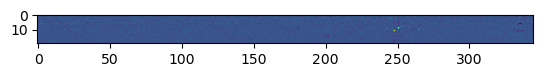

In [19]:
model = fit_seqf(bert_logits, mut_seq, logit_preds[:, 769])
mdelta = (torch.softmax(model.pos_logit,-1).detach().cpu().numpy() - torch.softmax(model.base_logit,-1).detach().cpu().numpy())
plt.imshow(mdelta.T)

model = fit_seqf(base_logit_l[8], mut_seq, logit_preds[:, 769])
mdelta = (torch.softmax(model.pos_logit,-1).detach().cpu().numpy() - torch.softmax(model.base_logit,-1).detach().cpu().numpy())
plt.imshow(mdelta.T)

test_eval_logits = torch.tensor(logit_preds_csr[8*7000:8*7000+7000].todense()[:, 769])
test_base_logits = base_logit_l[8]
test_mut_seq = mut_seq_l[8]
model = fit_seqf(bert_logits, test_mut_seq, test_eval_logits)
mdelta = (torch.softmax(model.pos_logit,-1).detach().cpu().numpy() - torch.softmax(model.base_logit,-1).detach().cpu().numpy())
plt.imshow(mdelta.T)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SeqFBayes(nn.Module):
    def __init__(self, base_logits):
        super().__init__()
        self.pos_logit = torch.nn.Parameter(base_logits.clone())
        self.neg_logit = torch.nn.Parameter(base_logits.clone())
        self.base_logit = base_logits
        self.logit_prior = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
    
    def forward(self, seq):
        log_prior = F.log_softmax(self.logit_prior, dim=0)
        ln, v = self.base_logit.shape
        pos_logprob = torch.log_softmax(self.pos_logit, dim=1)[torch.arange(ln).reshape(1, -1), seq].sum(dim=1)
        neg_logprob = torch.log_softmax(self.neg_logit, dim=1)[torch.arange(ln).reshape(1, -1), seq].sum(dim=1)
        joint_logprob = torch.stack([pos_logprob + log_prior[0], neg_logprob + log_prior[1]], dim=-1)
        base_logprob = torch.logsumexp(joint_logprob, dim=-1)
        pos_cond_prob = pos_logprob + log_prior[0] - base_logprob
        neg_cond_prob = neg_logprob + log_prior[1] - base_logprob
        return torch.stack([neg_cond_prob, pos_cond_prob], dim=-1)
    
def to_seqf_tok(tok, sl):
    tok = tok[:, 1:sl+1] - 4 #-4 to convert to pure aa tokens from BERT tokens
    tok[torch.logical_or(tok >= 20, tok <= 0)] = 0
    return tok

from go_ml.data_utils import ProtDataset, get_seq_collator
from torch.utils.data import DataLoader
collate_seqs = get_seq_collator(tokenizer, max_length=1024, add_special_tokens=True)

def fit_seqf(base_logits, mut_seq, eval_logits):
    mut_ds = ProtDataset(['csatest']*len(mut_seq), [x[0] for x in mut_seq])
    mut_dl = DataLoader(mut_ds, shuffle=False, batch_size=60, collate_fn=collate_seqs)
    mut_seq_tok = torch.cat([batch['seq_ind'] for batch in mut_dl])
    sl = min(len(mut_seq[0][0]), 1022)
    mut_seq_tok = to_seqf_tok(mut_seq_tok, sl).to(device)
    joint_logits = torch.stack([torch.zeros_like(eval_logits), eval_logits], dim=-1)
    mut_seq_target_log = torch.log_softmax(joint_logits, dim=-1)

    model = SeqFBayes(base_logits).to(device)
    mut_seq_tok = mut_seq_tok.to(device)
    mut_seq_target_log = mut_seq_target_log.to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=3e-4)
    base_logit = model.base_logit.to(device)
    # print(mut_seq_tok.shape, base_logit.shape)
    for epoch in range(500):
        logprob = model.forward(mut_seq_tok) # N x C
        # print(logprob.shape)
        # seq_loss = F.kl_div(logprob, mut_seq_target_log, log_target=True, reduction='batchmean')
        seq_loss = F.kl_div(logprob, mut_seq_target_log, log_target=True, reduction='batchmean')

        reg_loss = (F.kl_div(torch.log_softmax(model.pos_logit, dim=1), 
                        torch.log_softmax(base_logit, dim=1), 
                        log_target=True, reduction='sum') + 
                        F.kl_div(torch.log_softmax(model.neg_logit, dim=1), 
                        torch.log_softmax(base_logit, dim=1), 
                        log_target=True, reduction='sum')
                        )
        loss = seq_loss + 1e-1*reg_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

# model_l = []
# i = 0
# for base_logits, mut_seq, eval_logits in zip(base_logit_l, mut_seq_l, eval_logits_l):
#     model = fit_seqf(base_logits, mut_seq, eval_logits)
#     model_l.append(model.cpu())
#     i += 1

In [10]:
# import pickle
# with open('notebook_cache/lime_eval_models.pkl', 'wb') as f:
#     pickle.dump(model_l, f)
import pickle
with open('notebook_cache/lime_eval_models.pkl', 'rb') as f:
    model_l = pickle.load(f)

In [11]:
test_model = model_l[8]
mdelta = (torch.softmax(test_model.pos_logit, -1) - torch.softmax(test_model.base_logit, -1)).detach().cpu()

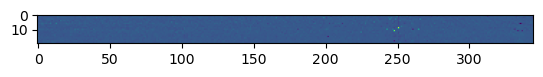

In [12]:
plt.imshow(mdelta.T)

In [19]:
bert_importance_val = torch.zeros(len(model_l), 1024).to(device) - 1e2
base_logit_l.append(bert_logits)
sl_l = []
for i, bert_logit in enumerate(base_logit_l[:100]):
    sl, ts = bert_logit.shape
    sl_l.append(sl)
    p = torch.softmax(bert_logit, dim=-1)
    res_entropy_imp = (torch.log(p)*p).sum(dim=-1)
    bert_importance_val[i, 1:sl+1] = res_entropy_imp
sl = np.array(sl_l)

In [28]:
annot_ind = [e['annot_ind'] for e in enzyme_l[:100]]
token_attribution = bert_importance_val.cpu().numpy()
token_labels = np.zeros_like(bert_importance_val.cpu())
for r in range(len(annot_ind)):
    token_labels[r, annot_ind[r]] = 1
seq_len = sl

In [30]:
from go_ml.eval_utils import mean_reciprocal_rank, mean_percent_rank
from sklearn.metrics import roc_curve, auc
import numpy as np

fpr_l, tpr_l, auc_l = [], [], []
for r in range(token_attribution.shape[0]):
    p_labels = token_labels[r, :seq_len[r]]
    p_attribution = token_attribution[r, :seq_len[r]]
    fpr, tpr, thresholds = roc_curve(p_labels, p_attribution)
    roc_auc = auc(fpr, tpr)
    fpr_l.append(fpr); tpr_l.append(tpr); 
    auc_l.append(roc_auc)

In [32]:
print(fpr_l[0])

[0.         0.00277008 0.00831025 0.00831025 0.01385042 0.01385042
 0.12742382 0.12742382 0.84210526 0.84210526 1.        ]


In [26]:
def roc_stats(token_attribution: np.ndarray, seq_len: np.ndarray, conserved_tokens):
    token_labels = np.zeros_like(token_attribution)
    for r in range(len(conserved_tokens)):
        token_labels[r, conserved_tokens[r]] = 1
    fpr_l, tpr_l, auc_l = [], [], []
    for r in range(token_attribution.shape[0]):
        p_labels = token_labels[r, :seq_len[r]]
        p_attribution = token_attribution[r, :seq_len[r]]
        fpr, tpr, thresholds = roc_curve(p_labels, p_attribution)
        roc_auc = auc(fpr, tpr)
        # fpr_l.append(fpr); tpr_l.append(tpr); 
        auc_l.append(roc_auc)
    # fpr_l = np.array(fpr_l); tpr_l = np.array(tpr_l); 
    auc_l = np.array(auc_l)
    return auc_l.mean()

# mrr = mean_reciprocal_rank(bert_importance_val, annot_ind)
# mpr = mean_percent_rank(bert_importance_val, sl, annot_ind)
# print('bert stats', mrr, mpr)
roc_metrics = roc_stats(bert_importance_val.cpu(), np.array(sl), annot_ind)
print(roc_metrics)

0.5533205924248984


In [34]:
diff_importance_val = torch.zeros(len(model_l), 1024).to(device)
sl_l = []
for i, model in enumerate(model_l):
    sl, ts = model.pos_logit.shape
    sl_l.append(sl)
    prob_diff = torch.log_softmax(model.pos_logit, dim=-1) - torch.log_softmax(model.neg_logit, dim=-1)
    max_diff = torch.max(prob_diff, dim=-1).values
    diff_importance_val[i, 1:sl+1] = max_diff
sl = torch.tensor(sl_l).to(device)
diff_importance_val = diff_importance_val.detach()
diff_importance_val = torch.nan_to_num(diff_importance_val, -1)

In [35]:
diff_base_importance_val = torch.zeros(len(model_l), 1024).to(device)
sl_l = []
for i, model in enumerate(model_l):
    sl, ts = model.pos_logit.shape
    sl_l.append(sl)
    prob_diff = torch.log_softmax(model.pos_logit, dim=-1) - torch.log_softmax(model.base_logit, dim=-1)
    max_diff = torch.max(prob_diff, dim=-1).values
    diff_base_importance_val[i, 1:sl+1] = max_diff
sl = torch.tensor(sl_l).to(device)
diff_base_importance_val = diff_base_importance_val.detach()
diff_base_importance_val = torch.nan_to_num(diff_base_importance_val, -1)

In [36]:
diff_entr_importance_val = torch.zeros(len(model_l), 1024).to(device)
sl_l = []
for i, model in enumerate(model_l):
    sl, ts = model.pos_logit.shape
    sl_l.append(sl)
    p = torch.softmax(model.pos_logit, dim=-1)
    pos_res_entropy = -(torch.log(p)*p).sum(dim=-1)
    p = torch.softmax(model.neg_logit, dim=-1)
    neg_res_entropy = -(torch.log(p)*p).sum(dim=-1)
    entr_diff = neg_res_entropy - pos_res_entropy
    diff_entr_importance_val[i, 1:sl+1] = entr_diff
sl = torch.tensor(sl_l).to(device)
diff_entr_importance_val = diff_entr_importance_val.detach()
diff_entr_importance_val = torch.nan_to_num(diff_entr_importance_val, -1)

In [37]:
pos_entr_importance_val = torch.zeros(len(model_l), 1024).to(device) - 1e2
sl_l = []
for i, model in enumerate(model_l):
    sl, ts = model.pos_logit.shape
    sl_l.append(sl)
    p = torch.softmax(model.pos_logit, dim=-1)
    pos_res_entropy = -(torch.log(p)*p).sum(dim=-1)
    pos_entr_importance_val[i, 1:sl+1] = -pos_res_entropy
sl = torch.tensor(sl_l).to(device)
pos_entr_importance_val = pos_entr_importance_val.detach()
pos_entr_importance_val = torch.nan_to_num(pos_entr_importance_val, -1)

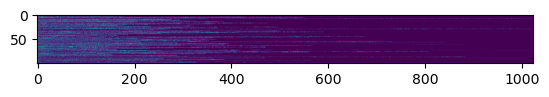

In [38]:
plt.imshow(diff_importance_val.cpu().numpy())
plt.show()

In [39]:
annot_ind = [e['annot_ind'] for e in enzyme_l[:100]]

In [41]:
from go_ml.eval_utils import mean_reciprocal_rank, mean_percent_rank
mrr = mean_reciprocal_rank(diff_importance_val, annot_ind)
mpr = mean_percent_rank(diff_importance_val, sl, annot_ind)
roc = roc_stats(diff_importance_val.cpu(), sl.cpu(), annot_ind)
print('diff_stats', mrr, mpr, roc)

mrr = mean_reciprocal_rank(diff_base_importance_val, annot_ind)
mpr = mean_percent_rank(diff_base_importance_val, sl, annot_ind)
roc = roc_stats(diff_base_importance_val.cpu(), sl.cpu(), annot_ind)
print('diff_base_stats', mrr, mpr, roc)

mrr = mean_reciprocal_rank(diff_entr_importance_val, annot_ind)
mpr = mean_percent_rank(diff_entr_importance_val, sl, annot_ind)
roc = roc_stats(diff_entr_importance_val.cpu(), sl.cpu(), annot_ind)
print('diff_entr_stats', mrr, mpr, roc)

mrr = mean_reciprocal_rank(pos_entr_importance_val, annot_ind)
mpr = mean_percent_rank(pos_entr_importance_val, sl, annot_ind)
roc = roc_stats(pos_entr_importance_val.cpu(), sl.cpu(), annot_ind)
print('pos_entr_stats', mrr, mpr, roc)

mrr = mean_reciprocal_rank(bert_importance_val, annot_ind)
mpr = mean_percent_rank(bert_importance_val, sl, annot_ind)
roc = roc_stats(bert_importance_val.cpu(), sl.cpu(), annot_ind)
print('bert stats', mrr, mpr, roc)

diff_stats tensor(0.0381, device='cuda:0') tensor(0.4666, device='cuda:0') 0.5416274950944537
diff_base_stats tensor(0.0381, device='cuda:0') tensor(0.4668, device='cuda:0') 0.5415411105266008
diff_entr_stats tensor(0.0410, device='cuda:0') tensor(1.5045, device='cuda:0') 0.5250271467980026
pos_entr_stats tensor(0.0428, device='cuda:0') tensor(0.4521, device='cuda:0') 0.554309793416499
bert stats tensor(0.0418, device='cuda:0') tensor(0.4534, device='cuda:0') 0.5533205924248984
